# Log and Logit GP Optimizers — a visual tour

`gpcam` provides two transform-aware optimizers for constrained observations:

- **`LogGPOptimizer`** for strictly positive values in $(0, \infty)$ — the GP is fit to $\log y$ and predictions on the original scale are guaranteed positive.
- **`LogitGPOptimizer`** for values bounded in $[0, 1]$ — the GP is fit to $\text{logit}(y)$ and predictions on the original scale are guaranteed inside $(0, 1)$.

Both classes also expose an `evaluate_posterior(x)` method that returns the *original-space* posterior summary: `median` (exact, because the link is monotone), exact credible intervals, and `mean`/`std` (closed-form lognormal for `LogGPOptimizer`, Monte-Carlo for `LogitGPOptimizer`). This notebook walks through both, with a plain `GPOptimizer` next to each for contrast.

In [1]:
import warnings
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import expit, logit

from gpcam import GPOptimizer, LogGPOptimizer, LogitGPOptimizer

np.random.seed(0)
plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": 0.3})
hp_bounds_1d = np.array([[1e-3, 1e1], [1e-3, 1e1]])  # signal variance, length scale (1D default kernel)

## 1. `LogGPOptimizer`: strictly positive observations

Truth: $f(x) = e^{0.8\sin(2\pi x) + 0.5}$ — always positive (range $\approx$ 0.45 to 4.95). Observations are multiplicatively noised so they stay positive.

In [2]:
def f_log(x):
    return np.exp(0.8 * np.sin(2.0 * np.pi * x) + 0.5)

n_train = 14
x_train = np.sort(np.random.uniform(0.05, 0.95, size=n_train))[:, None]
y_train = f_log(x_train[:, 0]) * np.exp(0.10 * np.random.randn(n_train))

print(f"y range: [{y_train.min():.3f}, {y_train.max():.3f}]  (all positive)")

y range: [0.723, 2.813]  (all positive)


### Fit a plain `GPOptimizer` and a `LogGPOptimizer` on the same data

In [3]:
plain_gp = GPOptimizer(x_train, y_train)
plain_gp.train(hyperparameter_bounds=hp_bounds_1d)

log_gp = LogGPOptimizer(x_train, y_train)
log_gp.train(hyperparameter_bounds=hp_bounds_1d)

/home/marcus/Coding/fvGP/fvgp/gp.py:375: UserWarning: Hyperparameters initialized to a vector of ones.
  warnings.warn("Hyperparameters initialized to a vector of ones.")
/home/marcus/Coding/fvGP/fvgp/gp.py:406: UserWarning: No noise function or measurement noise provided. Noise variances will be set to (0.01 * mean(|y_data|))^2.
  self.likelihood = GPlikelihood(self.data,


array([0.25971505, 0.04497138])

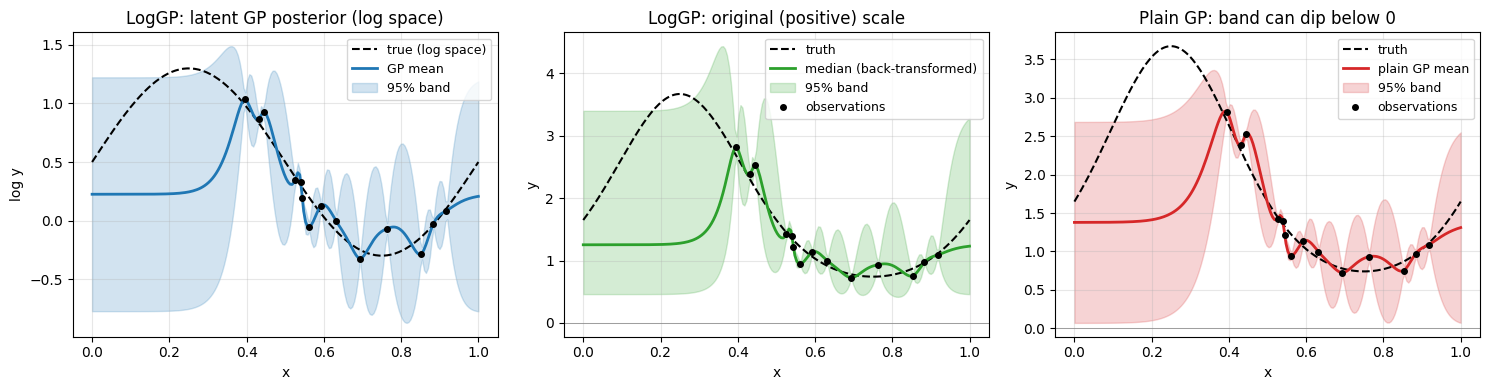

In [4]:
xg = np.linspace(0, 1, 200)[:, None]

plain_post = plain_gp.evaluate_posterior(xg)        # identity transform: Gaussian on the original scale
log_post = log_gp.evaluate_posterior(xg)            # mapped through exp -> original scale, guaranteed positive
log_mu = log_gp.posterior_mean(xg)["m(x)"]
log_sd = np.sqrt(log_gp.posterior_covariance(xg, variance_only=True)["v(x)"])

fig, ax = plt.subplots(1, 3, figsize=(15, 4))

# (a) Latent GP in log-space
ax[0].plot(xg[:, 0], np.log(f_log(xg[:, 0])), "k--", lw=1.5, label="true (log space)")
ax[0].plot(xg[:, 0], log_mu, color="C0", lw=2, label="GP mean")
ax[0].fill_between(xg[:, 0], log_mu - 1.96 * log_sd, log_mu + 1.96 * log_sd,
                   alpha=0.2, color="C0", label="95% band")
ax[0].plot(x_train[:, 0], np.log(y_train), "k.", ms=8)
ax[0].set_title("LogGP: latent GP posterior (log space)")
ax[0].set_xlabel("x"); ax[0].set_ylabel("log y")
ax[0].legend(loc="best", fontsize=9)

# (b) LogGP back-transformed to the original positive scale
ax[1].plot(xg[:, 0], f_log(xg[:, 0]), "k--", lw=1.5, label="truth")
ax[1].plot(xg[:, 0], log_post["median"], color="C2", lw=2, label="median (back-transformed)")
ax[1].fill_between(xg[:, 0], log_post["lower"], log_post["upper"],
                   alpha=0.2, color="C2", label="95% band")
ax[1].plot(x_train[:, 0], y_train, "k.", ms=8, label="observations")
ax[1].axhline(0, color="gray", lw=0.5)
ax[1].set_title("LogGP: original (positive) scale")
ax[1].set_xlabel("x"); ax[1].set_ylabel("y")
ax[1].legend(loc="best", fontsize=9)

# (c) Plain GP for contrast
ax[2].plot(xg[:, 0], f_log(xg[:, 0]), "k--", lw=1.5, label="truth")
ax[2].plot(xg[:, 0], plain_post["median"], color="C3", lw=2, label="plain GP mean")
ax[2].fill_between(xg[:, 0], plain_post["lower"], plain_post["upper"],
                   alpha=0.2, color="C3", label="95% band")
ax[2].plot(x_train[:, 0], y_train, "k.", ms=8, label="observations")
ax[2].axhline(0, color="gray", lw=0.5)
ax[2].set_title("Plain GP: band can dip below 0")
ax[2].set_xlabel("x"); ax[2].set_ylabel("y")
ax[2].legend(loc="best", fontsize=9)

plt.tight_layout()
plt.show()

The plain GP doesn't know the data is positive — its 95% band crosses zero, which is meaningless for an intensity, rate, or concentration. `LogGPOptimizer` fits the GP in log-space (left) and pushes the posterior back through `exp`, so the median and band on the original scale are guaranteed positive (middle).

## 2. `LogitGPOptimizer`: observations bounded in [0, 1]

Truth: $f(x) = \sigma(2\sin(3x) + 0.2)$. Observations are simulated as 10-trial binomial fractions, so some will land at exactly $0$ or $1$. `LogitGPOptimizer` clips boundary observations to $[\varepsilon, 1-\varepsilon]$ (with a warning) before the logit transform — `logit(0)`/`logit(1)` are infinite.

In [5]:
def f_logit(x):
    return expit(2.0 * np.sin(3.0 * x) + 0.2)

n_train2 = 22
x_train2 = np.sort(np.random.uniform(0.0, 2.0 * np.pi, size=n_train2))[:, None]
p_true = f_logit(x_train2[:, 0])
y_train2 = np.random.binomial(n=10, p=p_true) / 10.0  # fractions in {0, 0.1, ..., 1.0}

print(f"y range: [{y_train2.min()}, {y_train2.max()}]")
print(f"observations at boundary: 0 -> {int(np.sum(y_train2 == 0))}, "
      f"1 -> {int(np.sum(y_train2 == 1))}")

y range: [0.0, 1.0]
observations at boundary: 0 -> 2, 1 -> 1


In [6]:
plain_gp2 = GPOptimizer(x_train2, y_train2)
plain_gp2.train(hyperparameter_bounds=hp_bounds_1d)

with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    logit_gp = LogitGPOptimizer(x_train2, y_train2)
    logit_gp.train(hyperparameter_bounds=hp_bounds_1d)

for w in caught:
    if "clipped" in str(w.message):
        print(f"  {w.message}")

  LogitGPOptimizer clipped observations to [1e-06, 0.999999] before the logit transform.


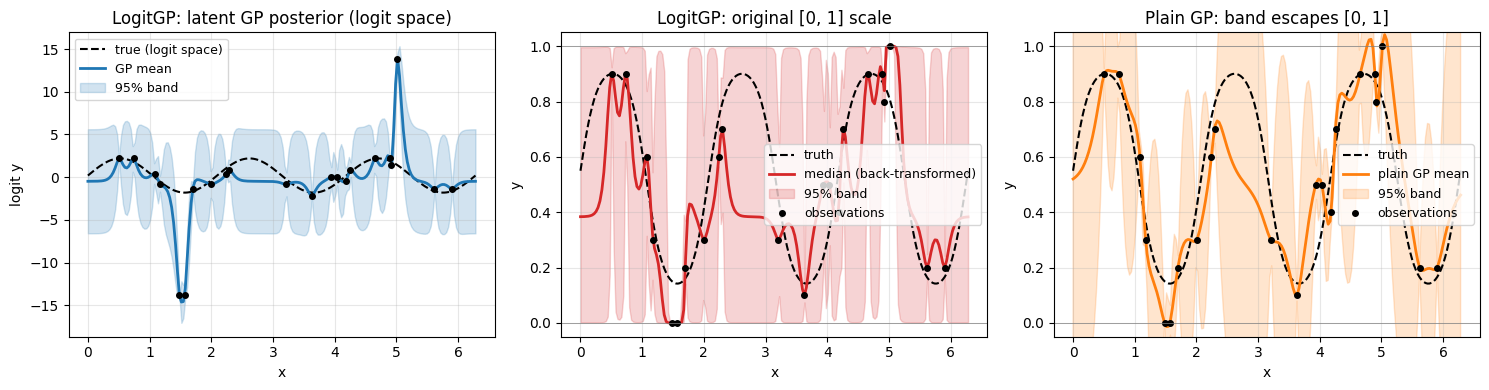

In [7]:
xg2 = np.linspace(0, 2.0 * np.pi, 200)[:, None]

plain_post2 = plain_gp2.evaluate_posterior(xg2)
logit_post = logit_gp.evaluate_posterior(xg2)
logit_mu = logit_gp.posterior_mean(xg2)["m(x)"]
logit_sd = np.sqrt(logit_gp.posterior_covariance(xg2, variance_only=True)["v(x)"])

# For the logit-space scatter, clip observations the same way the optimizer did
y_train2_clip = np.clip(y_train2, 1e-6, 1 - 1e-6)

fig, ax = plt.subplots(1, 3, figsize=(15, 4))

# (a) Latent GP in logit space
ax[0].plot(xg2[:, 0], logit(f_logit(xg2[:, 0])), "k--", lw=1.5, label="true (logit space)")
ax[0].plot(xg2[:, 0], logit_mu, color="C0", lw=2, label="GP mean")
ax[0].fill_between(xg2[:, 0], logit_mu - 1.96 * logit_sd, logit_mu + 1.96 * logit_sd,
                   alpha=0.2, color="C0", label="95% band")
ax[0].plot(x_train2[:, 0], logit(y_train2_clip), "k.", ms=8)
ax[0].set_title("LogitGP: latent GP posterior (logit space)")
ax[0].set_xlabel("x"); ax[0].set_ylabel("logit y")
ax[0].legend(loc="best", fontsize=9)

# (b) LogitGP back-transformed
ax[1].plot(xg2[:, 0], f_logit(xg2[:, 0]), "k--", lw=1.5, label="truth")
ax[1].plot(xg2[:, 0], logit_post["median"], color="C3", lw=2, label="median (back-transformed)")
ax[1].fill_between(xg2[:, 0], logit_post["lower"], logit_post["upper"],
                   alpha=0.2, color="C3", label="95% band")
ax[1].plot(x_train2[:, 0], y_train2, "k.", ms=8, label="observations")
ax[1].axhline(0, color="gray", lw=0.5)
ax[1].axhline(1, color="gray", lw=0.5)
ax[1].set_ylim(-0.05, 1.05)
ax[1].set_title("LogitGP: original [0, 1] scale")
ax[1].set_xlabel("x"); ax[1].set_ylabel("y")
ax[1].legend(loc="best", fontsize=9)

# (c) Plain GP for contrast
ax[2].plot(xg2[:, 0], f_logit(xg2[:, 0]), "k--", lw=1.5, label="truth")
ax[2].plot(xg2[:, 0], plain_post2["median"], color="C1", lw=2, label="plain GP mean")
ax[2].fill_between(xg2[:, 0], plain_post2["lower"], plain_post2["upper"],
                   alpha=0.2, color="C1", label="95% band")
ax[2].plot(x_train2[:, 0], y_train2, "k.", ms=8, label="observations")
ax[2].axhline(0, color="gray", lw=0.5)
ax[2].axhline(1, color="gray", lw=0.5)
ax[2].set_ylim(-0.05, 1.05)
ax[2].set_title("Plain GP: band escapes [0, 1]")
ax[2].set_xlabel("x"); ax[2].set_ylabel("y")
ax[2].legend(loc="best", fontsize=9)

plt.tight_layout()
plt.show()

The plain GP's credible band frequently leaves [0, 1] — for a fraction or probability that's nonsense. `LogitGPOptimizer` fits the GP in logit-space (left) and pushes the posterior through the sigmoid, so the entire band stays inside (0, 1) (middle).

## 3. Sampling the original-space posterior

Both optimizers can also return Monte-Carlo samples of the original-scale posterior via `evaluate_posterior(x, return_samples=True, n_samples=N)`. The returned dict gains a `"samples"` array of shape `(n_points, n_samples)` (the i-th row are the samples at $x_i$), so users can plot histograms, compute quantiles, or take expectations of arbitrary functions. Below we draw the posterior at one $x$ for each class to show the characteristic shape — lognormal (right-skewed, positive only) for `LogGPOptimizer`, logistic-normal (bounded in $(0,1)$) for `LogitGPOptimizer`.

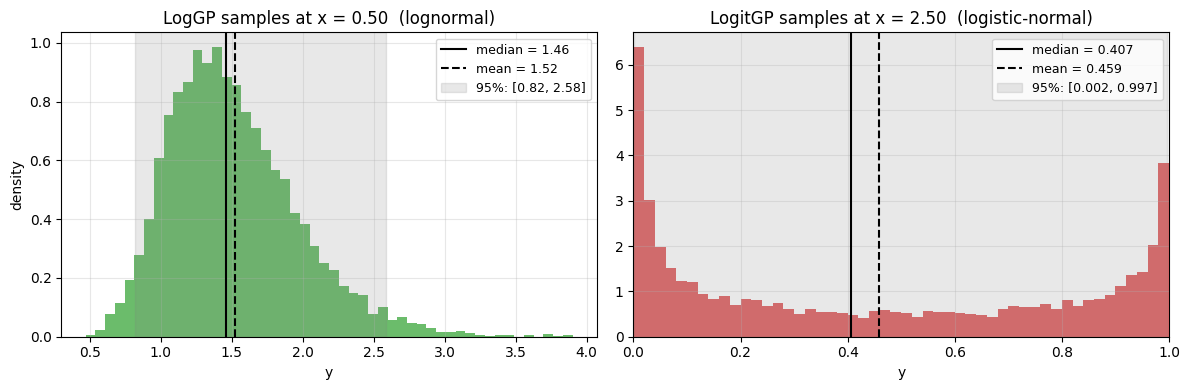

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# LogGP samples at a single x
xq_log = np.array([[0.50]])
ep_log_s = log_gp.evaluate_posterior(xq_log, return_samples=True, n_samples=8000)
s = ep_log_s["samples"][0]
ax[0].hist(s, bins=50, color="C2", alpha=0.7, density=True)
ax[0].axvline(ep_log_s["median"][0], color="k", lw=1.5,
              label=f"median = {ep_log_s['median'][0]:.2f}")
ax[0].axvline(ep_log_s["mean"][0], color="k", lw=1.5, ls="--",
              label=f"mean = {ep_log_s['mean'][0]:.2f}")
ax[0].axvspan(ep_log_s["lower"][0], ep_log_s["upper"][0], color="gray", alpha=0.18,
              label=f"95%: [{ep_log_s['lower'][0]:.2f}, {ep_log_s['upper'][0]:.2f}]")
ax[0].set_xlabel("y"); ax[0].set_ylabel("density")
ax[0].set_title(f"LogGP samples at x = {xq_log[0, 0]:.2f}  (lognormal)")
ax[0].legend(loc="best", fontsize=9)

# LogitGP samples at a single x
xq_logit = np.array([[2.50]])
ep_logit_s = logit_gp.evaluate_posterior(xq_logit, return_samples=True, n_samples=8000)
s = ep_logit_s["samples"][0]
ax[1].hist(s, bins=50, color="C3", alpha=0.7, density=True)
ax[1].axvline(ep_logit_s["median"][0], color="k", lw=1.5,
              label=f"median = {ep_logit_s['median'][0]:.3f}")
ax[1].axvline(ep_logit_s["mean"][0], color="k", lw=1.5, ls="--",
              label=f"mean = {ep_logit_s['mean'][0]:.3f}")
ax[1].axvspan(ep_logit_s["lower"][0], ep_logit_s["upper"][0], color="gray", alpha=0.18,
              label=f"95%: [{ep_logit_s['lower'][0]:.3f}, {ep_logit_s['upper'][0]:.3f}]")
ax[1].set_xlim(0, 1)
ax[1].set_xlabel("y")
ax[1].set_title(f"LogitGP samples at x = {xq_logit[0, 0]:.2f}  (logistic-normal)")
ax[1].legend(loc="best", fontsize=9)

plt.tight_layout()
plt.show()

## Takeaways

- Use **`LogGPOptimizer`** when measurements are guaranteed positive — predictions and intervals stay positive, and the original-scale mean is the closed-form lognormal mean.
- Use **`LogitGPOptimizer`** when measurements are bounded in $[0, 1]$ — predictions and intervals stay inside $(0, 1)$, and boundary observations are safely clipped.
- For both, the inherited `posterior_mean` / `posterior_covariance` return the Gaussian posterior in the *transformed* space; call **`evaluate_posterior(x)`** to get the original-scale summary (`median`, exact credible band, plus `mean`/`std`). Pass `return_samples=True` to also get raw posterior samples for histograms or custom quantities.
- The full `GPOptimizer` API (training, `ask`, acquisition functions) is inherited — the transform is invisible to the rest of the workflow.